# Benchmarking the Tuna devices performance using common measurement routines

**Author:** Marios Samiotis (m.samiotis@tudelft.nl)

**Date:** April 29, 2026

**Last updated:** April 29, 2026

# 1. Introduction

In this notebook we will use some of the most common benchmark measurement routines to assess the performance of any of the Tuna superconducting quantum backends which exist at the [Quantum Inspire 2.0](https://www.quantum-inspire.com/) cloud services.

Prior to using this notebook, for optimal performance, make sure that you are running it within a customized Python 3.12 environment which includes the packages "quantuminspire" and "qiskit-quantuminspire".

For details on how to create such a Python environment, follow the installation instructions in the [README file](https://github.com/DiCarloLab-Delft/QuantumInspireUtilities/blob/main/README.md).

Useful links:
1. [Tuna Backends Operational Specifics](https://www.quantum-inspire.com/kbase/tuna-operational-specifics/)
2. [Backend Performance Dashboards](https://monitoring.qutech.support/public-dashboards/c494a21fb6b7405f850ab8f340f798ef?orgId=1&refresh=10s) [live updates]
3. [Join our Slack community!](https://join.slack.com/t/qisuperconducting/shared_invite/zt-35o7zitdh-_9QPmB53hhLy12Eat5gwWA)

First, we run the following cell in order to login to the Quantum Inspire platform. You need an account in order to login to the platform.

Please click on "Confirm" in the pop-up browser window to login.

In [1]:
! qi login "https://api.quantum-inspire.com"

Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=FPZH-ZNTC in your browser
If promped to verify a code, please confirm it is as follows: FPZH-ZNTC
Login successful!
Using member ID 10


Run the following cell for all necessary library imports,

In [2]:
import numpy as np
from qiskit_quantuminspire.qi_provider import QIProvider
from qi_utilities.device_simulation.simulators import NoisySimulator # use the simulator in case all backends are unavailable!
from qi_utilities.measurements.device_control import DeviceControl

# 2. Connecting to the backend

We first connect to the Quantum Inspire provider, by running the following cell,

In [3]:
provider = QIProvider()

The following command prints the full list of all available backends of the platform,

In [4]:
provider.backends()

[<qiskit_quantuminspire.qi_backend.QIBackend object at 0x111e002f0 (name=QX emulator, id=1)>,
 <qiskit_quantuminspire.qi_backend.QIBackend object at 0x103d19d90 (name=Tuna-5, id=4)>,
 <qiskit_quantuminspire.qi_backend.QIBackend object at 0x11335cec0 (name=Ry emulator, id=5)>,
 <qiskit_quantuminspire.qi_backend.QIBackend object at 0x1139f3f20 (name=Tuna-9, id=6)>,
 <qiskit_quantuminspire.qi_backend.QIBackend object at 0x1113b5ee0 (name=Tuna-17, id=7)>]

We now connect to a Tuna backend by running the following cell,

In [5]:
backend_name = "Tuna-9"
backend = provider.get_backend(name=backend_name)

In [ ]:
backend = NoisySimulator("Starmon-7")

By running the cell below, the connectivity of the processor is shown (otherwise known as "coupling map"),

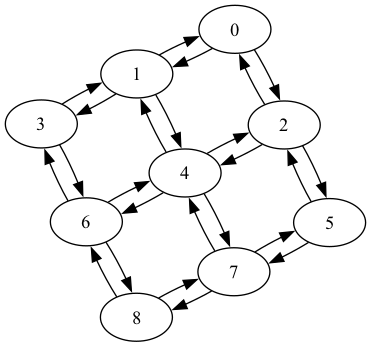

In [6]:
backend.coupling_map.draw()

Any single- or multi-qubit gates that may be applied on the qubits of the Tuna backends are referred to as "instructions". The full list of allowed instructions of the Tuna backend is shown by running the following cell,

In [ ]:
backend.instructions

When executing a quantum algorithm on any backend, one needs to choose the number of measurement shots to be performed for the given quantum circuit. The maximum number of allowed shots on the Tuna backend can be obtained by running the command

In [ ]:
backend.max_shots

# DeviceControl class

In [7]:
device = DeviceControl(backend)

In [9]:
device.measure_rabi(qubit_list=[5, 6],
                    rotation_angles = np.linspace(0, 2*np.pi, num=29))

In [8]:
device.measure_T1(qubit_list=[5, 6],
                  measurement_times=np.linspace(0, 120e-6, num=31))

{'Q5 [us]': np.float64(25.852744079623804), 'Q6 [us]': np.float64(21.328253370551547)}
